use benettin algorithm


The Benettin algorithm is the gold standard for numerically calculating Lyapunov exponents. Because chaotic systems cause trajectories to diverge exponentially, if you just let two simulated pendulums run, they will quickly fly apart to the maximum extent allowed by the system. Once that happens, you are no longer measuring the rate of chaos—you are just measuring the physical boundaries of the pendulum's reach.The genius of Giancarlo Benettin and his colleagues was to introduce a periodic "pull-back" or renormalization step.Here is exactly how the algorithm works, broken down step-by-step.The Step-by-Step Breakdown1. The Setup (Fiducial and Shadow)First, you define your main system state $X$, which is a 4D vector for the double pendulum containing $[\theta_1, \theta_2, \dot{\theta}_1, \dot{\theta}_2]$. This is called your fiducial trajectory.Next, you create a "shadow" or perturbed trajectory, let's call it $Y$. You create it by adding an incredibly small initial displacement vector $d_0$ to your fiducial trajectory:$$Y_0 = X_0 + d_0$$The length of this tiny bridge between them is $L_0 = ||d_0||$ (usually set around $10^{-8}$).2. The EvolutionYou use a numerical integrator (like Runge-Kutta 4th order) to push both $X$ and $Y$ forward in time by a small time step, $\Delta t$. $X_0 \to X_1$, $Y_0 \to Y'_1$ 3. The MeasurementAfter time $\Delta t$, chaos will have pushed them apart. You calculate the new distance between them:$$d'_1 = Y'_1 - X_1$$Let's call the length of this new vector $L_1 = ||d'_1||$. Because of the chaotic nature of the double pendulum, $L_1$ will almost certainly be larger than $L_0$.You compute the local growth rate for this step: $\ln(L_1 / L_0)$.4. The Rescaling (The "Pull-Back")Here is the core of the algorithm. To keep the shadow trajectory from flying off to infinity, you shrink the distance back down to the original $L_0$, but you keep the direction in phase space that the system naturally wanted to expand in.You define the new starting point for the shadow trajectory as:$$Y_1 = X_1 + L_0 \left( \frac{d'_1}{L_1} \right)$$5. Rinse and RepeatNow you repeat steps 2 through 4 for $N$ total steps (where $N$ is a large number). At each step $i$, you measure the new distance $L_i$ and rescale.Calculating the ExponentTo get the actual Lyapunov exponent ($\lambda$), you take the average of all those local growth rates you logged over the total time elapsed:$$\lambda = \lim_{N \to \infty} \frac{1}{N \Delta t} \sum_{i=1}^{N} \ln \left( \frac{L_i}{L_0} \right)$$If $\lambda > 0$, the system is chaotic.If $\lambda \le 0$, the system is stable or periodic.Would you like me to give you a basic Python code structure that implements this loop for a double pendulum?

In [29]:
import numpy as np
import taichi as ti
ti.init(arch=ti.gpu, default_fp=ti.f64)

[Taichi] Starting on arch=cuda


In [30]:
num_sims = (500, 1000)
calculation_time = 300

sims = ti.Vector.field(4, ti.float32, shape=(num_sims[0], num_sims[1], 2)) # the 2 is for a base sim and a displaced sim
l_sum = ti.field(ti.float32, shape=num_sims)

L0 = 1e-1

In [31]:
@ti.func
def map_range(value: float, min_in: float, max_in: float, min_out: float, max_out: float) -> float:
    return (value - min_in) / (max_in - min_in) * (max_out - min_out) + min_out

In [32]:
@ti.kernel
def setup(theta_range: ti.math.vec2, phi_range: ti.math.vec2):
    for i, j in l_sum:
        theta_0 = map_range(i, 0, num_sims[0], theta_range[0], theta_range[1])
        phi_0 = map_range(j, 0, num_sims[1], phi_range[0], phi_range[1])

        displacement = L0*ti.math.normalize(ti.Vector([ti.random(), ti.random(), ti.random(), ti.random()]))

        sims[i, j, 0] = ti.Vector([theta_0, 0, phi_0, 0])
        sims[i, j, 1] = ti.Vector([theta_0, 0, phi_0, 0]) + displacement
        l_sum[i, j] = 0

In [33]:
@ti.func
def get_angular_acceleration_theta(theta: float, theta_d: float, phi: float, phi_d: float, Rcm: float, rcm: float, I_1: float, I_2: float, m_1: float, m_2: float, l: float, g: float) -> float:
    return (-1/2*theta_d**2*rcm**2*l**2*m_2**2*ti.sin(2*theta - 2*phi) - phi_d**2*rcm*I_2*l*m_2*ti.sin(theta - phi) + rcm**2*g*l*m_2**2*ti.sin(phi)*ti.cos(theta - phi) - Rcm*I_2*g*m_1*ti.sin(theta) - I_2*g*l*m_2*ti.sin(theta))/(-rcm**2*l**2*m_2**2*ti.cos(theta - phi)**2 + I_1*I_2 + I_2*l**2*m_2)

@ti.func
def get_angular_acceleration_phi(theta: float, theta_d: float, phi: float, phi_d: float, Rcm: float, rcm: float, I_1: float, I_2: float, m_1: float, m_2: float, l: float, g: float) -> float:
    return (1/2)*rcm*m_2*(2*theta_d**2*I_1*l*ti.sin(theta - phi) + 2*theta_d**2*l**3*m_2*ti.sin(theta - phi) + phi_d**2*rcm*l**2*m_2*ti.sin(2*theta - 2*phi) + Rcm*g*l*m_1*ti.sin(phi) + Rcm*g*l*m_1*ti.sin(2*theta - phi) - 2*I_1*g*ti.sin(phi) - g*l**2*m_2*ti.sin(phi) + g*l**2*m_2*ti.sin(2*theta - phi))/(-rcm**2*l**2*m_2**2*ti.cos(theta - phi)**2 + I_1*I_2 + I_2*l**2*m_2)

@ti.func
def f(y: ti.math.vec4, Rcm: float, rcm: float, I_1: float, I_2: float, m_1: float, m_2: float, l:float, g: float) -> ti.math.vec4:
    return ti.Vector([
        y[1],
        get_angular_acceleration_theta(y[0], y[1], y[2], y[3], Rcm, rcm, I_1, I_2, m_1, m_2, l, g),
        y[3],
        get_angular_acceleration_phi(y[0], y[1], y[2], y[3], Rcm, rcm, I_1, I_2, m_1, m_2, l, g)
    ])


In [34]:
h = 0.001  # simulation time increment

@ti.kernel
def update():
    m_1 = 108.5e-3
    m_2 = 86e-3
    I1 = 0.00216
    I2 = 0.00103
    Rcm = 11.7e-2
    rcm = 9.225e-2
    l = 19.59e-2
    l2 = 14.64e-2
    g = 9.81

    for i, j, k in sims:
        oldValue = sims[i, j, k]
        k1 = h * f(oldValue, Rcm, rcm, I1, I2, m_1, m_2, l, g)
        k2 = h * f(oldValue + k1/2, Rcm, rcm, I1, I2, m_1, m_2, l, g)
        k3 = h * f(oldValue + k2/2, Rcm, rcm, I1, I2, m_1, m_2, l, g)
        k4 = h * f(oldValue + k3, Rcm, rcm, I1, I2, m_1, m_2, l, g)

        newValue = oldValue + k1/6 + k2/3 + k3/3 + k4/6
        sims[i, j, k] = newValue

In [35]:
@ti.kernel
def sum_and_renormalize():
    for i, j in l_sum:
        base = sims[i, j, 0]
        displaced = sims[i, j, 1]

        displacement = displaced - base
        displacement_mag = ti.math.length(displacement)
        displacement_mag = ti.max(displacement_mag, 1e-15)
        l_sum[i, j] += ti.math.log(displacement_mag/L0)

        renormalized_displacement = base + displacement * (L0/displacement_mag)
        sims[i, j, 1] = renormalized_displacement

In [36]:
pixels = ti.Vector.field(3, ti.f32, shape=(num_sims[0], num_sims[1]))


@ti.func
def colormap(val: float) -> ti.math.vec3:
    # val = 1-val
    x = ti.max(0.0, ti.min(1.0, val))

    # A simplified Magma approximation
    r = 1.0 - ti.pow(1.0 - x, 3.0)
    g = ti.pow(x, 3.0) + 0.2 * ti.sin(3.14 * x)
    b = 0.2 + 0.6 * ti.pow(x, 5.0)

    return ti.Vector([ti.math.clamp(r, 0, 1),
                      ti.math.clamp(g, 0, 1),
                      ti.math.clamp(b, 0, 1)])
@ti.func
def smooth_mod(x, n):
    return x - n * ti.floor(x / n)

@ti.kernel
def draw():
    for i, j in pixels:
        
        # v = l_sum[i, j]
        # pixels[i, j] = colormap(map_range(v, 0, 10, 0, 1))

        pixels[i, j] = ti.Vector([
            smooth_mod(sims[i, j, 0][0], 2*ti.math.pi) / (2*ti.math.pi),
            smooth_mod(sims[i, j, 0][2], 2*ti.math.pi) / (2*ti.math.pi),
            0
        ])

In [37]:
window = ti.ui.Window("Visualization", (800, 800))
canvas = window.get_canvas()

theta_range = (0, np.pi)
phi_range = (-np.pi, np.pi)
# theta_range = (0, 2*np.pi)
# phi_range = (0, 2*np.pi)

setup(theta_range, phi_range)

N = int(calculation_time/h)
for i in range(N):
    update()
    sum_and_renormalize()

    if (i % 1000 == 0):
        print(str(100*i/N) + "%")

    # if (i % 100 == 0):
    # draw()
    # canvas.set_image(pixels)
    # window.show()

window.destroy()

sums = l_sum.to_numpy()
sums /= calculation_time

0.0%
0.3333333333333333%
0.6666666666666666%
1.0%
1.3333333333333333%
1.6666666666666667%
2.0%
2.3333333333333335%
2.6666666666666665%
3.0%
3.3333333333333335%
3.6666666666666665%
4.0%
4.333333333333333%
4.666666666666667%
5.0%
5.333333333333333%
5.666666666666667%
6.0%
6.333333333333333%
6.666666666666667%
7.0%
7.333333333333333%
7.666666666666667%
8.0%
8.333333333333334%
8.666666666666666%
9.0%
9.333333333333334%
9.666666666666666%
10.0%
10.333333333333334%
10.666666666666666%
11.0%
11.333333333333334%
11.666666666666666%
12.0%
12.333333333333334%
12.666666666666666%
13.0%
13.333333333333334%
13.666666666666666%
14.0%
14.333333333333334%
14.666666666666666%
15.0%
15.333333333333334%
15.666666666666666%
16.0%
16.333333333333332%
16.666666666666668%
17.0%
17.333333333333332%
17.666666666666668%
18.0%
18.333333333333332%
18.666666666666668%
19.0%
19.333333333333332%
19.666666666666668%
20.0%
20.333333333333332%
20.666666666666668%
21.0%
21.333333333333332%
21.666666666666668%
22.0%
22.3

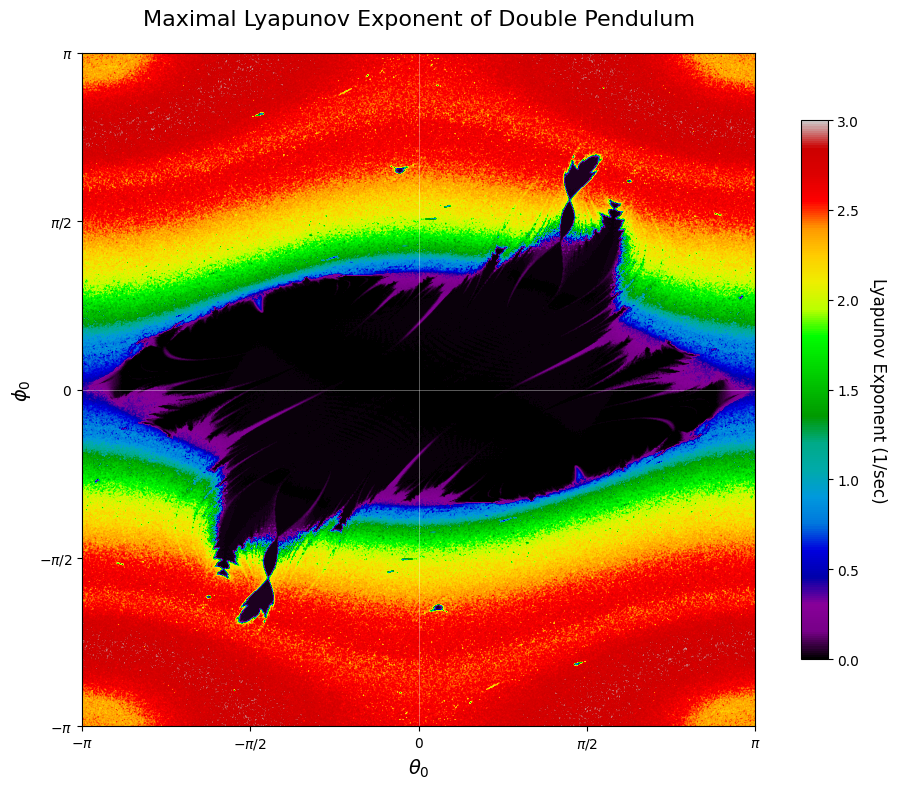

In [38]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# --- 1. Data Prep (CRITICAL FOR A CLEAN MAP) ---
# Assuming 'sums' is your raw (100, 100) NumPy array from Taichi.
data = sums.copy()

# A. CLIP THE SPIKES: In your 3D plot, exponents hit 20+. 
# We must limit the visualization range to see any detail in the physical range (0 to 2.0).
upper_limit = 3
data_clipped = np.clip(data, a_min=0, a_max=upper_limit)

# B. FLOOR THE STABILITY: Treat very small values as zero 
# to make the stable islands pop.
data_final = data_clipped

flipped = np.flip(data_final)
flipped_sliced = flipped[:-1, :]
data_final_square = np.vstack((flipped_sliced, data_final))

# --- 2. Set Up the Visualization ---
# Use ranges from your setup: theta_range = (-np.pi, np.pi)
# The 'extent' maps the array indices (0-99) to these physical values.
extent = [-np.pi, np.pi, -np.pi, np.pi]

fig, ax = plt.subplots(figsize=(10, 8))

# --- 3. Generate the Heatmap ---
# We use 'imshow'. 'origin="lower"' ensures (-pi, -pi) is in the bottom-left corner.
# 'interpolation="nearest"' shows the actual raw pixels (best for analyzing grid data).
heatmap = ax.imshow(data_final_square, 
                    extent=extent, 
                    origin='lower', 
                    cmap=cm.nipy_spectral, # 'magma', 'inferno', and 'viridis' are great choices
                    interpolation='gaussian',
                    norm=Normalize(vmin=0, vmax=upper_limit)) # Force the color scale


# --- 4. Styling and Labels ---
ax.set_title('Maximal Lyapunov Exponent of Double Pendulum', fontsize=16, pad=20)
ax.set_xlabel(r'$\theta_0$', fontsize=14)
ax.set_ylabel(r'$\phi_0$', fontsize=14)

# Set ticks at key intervals of pi
ticks = [-np.pi, -np.pi/2, 0, np.pi/2, np.pi]
tick_labels = [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels)

# --- 5. Add a Scientifically Robust Colorbar ---
cbar = fig.colorbar(heatmap, ax=ax, shrink=0.8)
cbar.set_label('Lyapunov Exponent (1/sec)', rotation=270, labelpad=20, fontsize=12)

# Optional: Draw lines for the axes
ax.axhline(0, color='white', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='white', linewidth=0.5, alpha=0.5)

plt.savefig('double_pendulum_fractal_4k.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [39]:
data_final_square

array([[2.474363 , 2.2832782, 2.381817 , ..., 2.3726337, 2.4350271,
        2.2529528],
       [2.3328688, 2.4215376, 2.4581287, ..., 2.4306016, 2.423742 ,
        2.3561504],
       [2.469531 , 2.4025695, 2.442631 , ..., 2.2799861, 2.346897 ,
        2.2664483],
       ...,
       [2.2664483, 2.346897 , 2.2799861, ..., 2.442631 , 2.4025695,
        2.469531 ],
       [2.3561504, 2.423742 , 2.4306016, ..., 2.4581287, 2.4215376,
        2.3328688],
       [2.2529528, 2.4350271, 2.3726337, ..., 2.381817 , 2.2832782,
        2.474363 ]], dtype=float32)